## Import Library


In [ ]:
import pandas as pd
import numpy as np
from openpyxl import load_workbook
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import silhouette_score

##Data Understanding


In [ ]:
df = pd.read_excel('/content/dataTraveloka.xlsx', usecols=range(11))

print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

print(df.columns)

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

                            Hotel Name Original price Price after discount  \
0         The Anvaya Beach Resort Bali   Rp 5.022.000         Rp 4.017.600   
1            The Apurva Kempinski Bali  Rp 14.520.640        Rp 10.890.480   
2     The Westin Resort Nusa Dua, Bali   Rp 4.001.067         Rp 3.000.800   
3  The Sakala Resort Bali - All Suites   Rp 2.400.000         Rp 1.392.000   
4         Discovery Kartika Plaza Bali   Rp 1.733.333         Rp 1.300.000   

                  Tax  Rating                          location  \
0  Inclusive of taxes     8.9                        Kuta, Bali   
1  Inclusive of taxes     8.9              Nusa Dua Beach, Bali   
2  Inclusive of taxes     8.8  The Westin Resort Nusa Dua, Bali   
3  Inclusive of taxes     8.5               Tanjung Benoa, Bali   
4  Inclusive of taxes     8.6                        Kuta, Bali   

                                            Facility  \
0  Daily housekeeping, 2 restaurants and bar/loun...   
1  Spa, Private 

##Data Cleaning

In [ ]:
print("Nilai kosong sebelum diisi:")
print(df.isnull().sum())

df.drop(columns=['Hotel Picture'], inplace=True)

df['Room Type'] = df['Room Type'].fillna(df['Room Type'].mode()[0])

df['Rating'] = df['Rating'].fillna(df['Rating'].mean())

df['Original price'] = df['Original price'].replace({'Rp ': '', r'\.': ''}, regex=True).astype(float)
df['Price after discount'] = df['Price after discount'].replace({'Rp ': '', r'\.': ''}, regex=True).astype(float)

df.drop_duplicates(inplace=True)

Nilai kosong sebelum diisi:
Hotel Name                 0
Original price             0
Price after discount       0
Tax                        0
Rating                    27
location                   0
Facility                   0
Room Type                  2
Room Size                  0
Hotel Picture           1012
Review                     0
dtype: int64


In [ ]:
print("\nNilai kosong setelah diisi:")
print(df.isnull().sum())

print("\nInformasi dataset setelah cleaning:")
print(df.info())

print("\nRingkasan Statistik:")
print(df.describe(include='all'))


Nilai kosong setelah diisi:
Hotel Name              0
Original price          0
Price after discount    0
Tax                     0
Rating                  0
location                0
Facility                0
Room Type               0
Room Size               0
Review                  0
dtype: int64

Informasi dataset setelah cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 994 entries, 0 to 1011
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Hotel Name            994 non-null    object 
 1   Original price        994 non-null    float64
 2   Price after discount  994 non-null    float64
 3   Tax                   994 non-null    object 
 4   Rating                994 non-null    float64
 5   location              994 non-null    object 
 6   Facility              994 non-null    object 
 7   Room Type             994 non-null    object 
 8   Room Size             994 non-null    object 

##Exploratory Data Analysis (EDA)

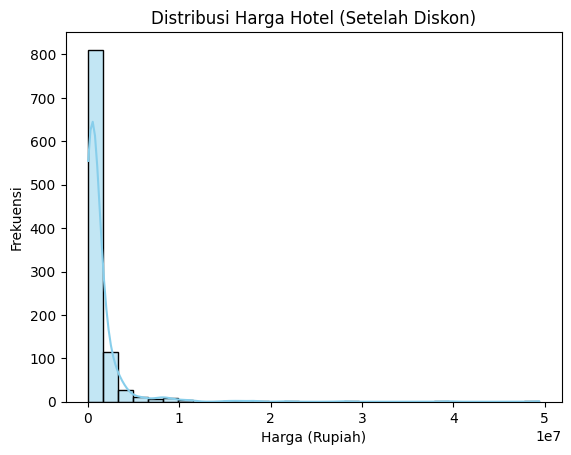

In [ ]:
sns.histplot(df['Price after discount'], kde=True, bins=30, color='skyblue')
plt.title('Distribusi Harga Hotel (Setelah Diskon)')
plt.xlabel('Harga (Rupiah)')
plt.ylabel('Frekuensi')
plt.show()

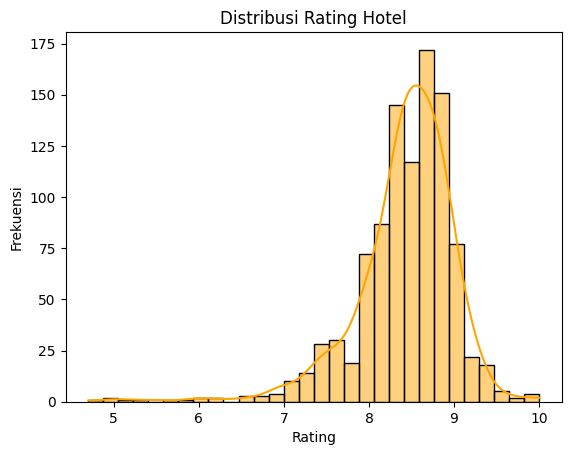

In [ ]:
sns.histplot(df['Rating'], kde=True, bins=30, color='orange')
plt.title('Distribusi Rating Hotel')
plt.xlabel('Rating')
plt.ylabel('Frekuensi')
plt.show()

/tmp/ipython-input-4112097647.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_locations.index, x=top_locations.values, palette="viridis")


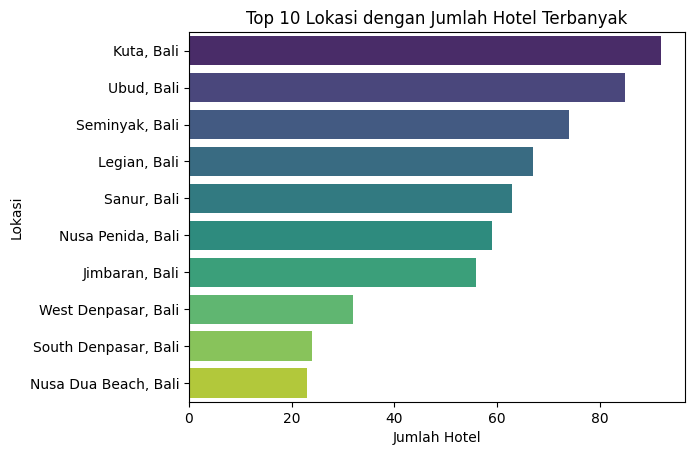

In [ ]:
top_locations = df['location'].value_counts().head(10)
sns.barplot(y=top_locations.index, x=top_locations.values, palette="viridis")
plt.title('Top 10 Lokasi dengan Jumlah Hotel Terbanyak')
plt.xlabel('Jumlah Hotel')
plt.ylabel('Lokasi')
plt.show()

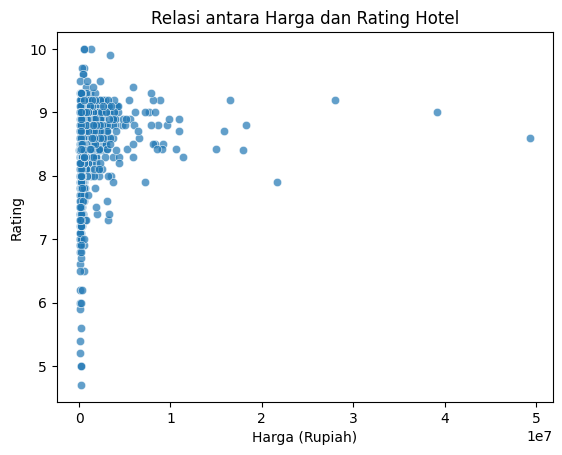

In [ ]:
sns.scatterplot(x='Price after discount', y='Rating', data=df, alpha=0.7)
plt.title('Relasi antara Harga dan Rating Hotel')
plt.xlabel('Harga (Rupiah)')
plt.ylabel('Rating')
plt.show()

/tmp/ipython-input-3340465069.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_rooms.index, x=top_rooms.values, palette='mako')


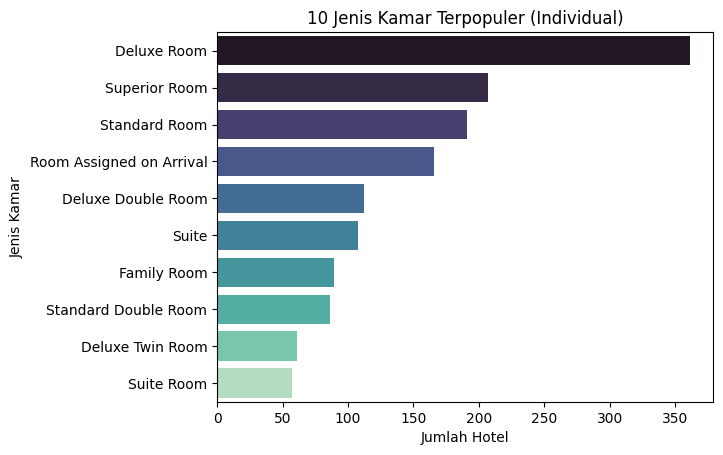

In [ ]:
room_split = df['Room Type'].dropna().apply(lambda x: [r.strip() for r in x.split(',')])

all_rooms = [room for sublist in room_split for room in sublist]

room_counts = Counter(all_rooms)

top_rooms = pd.Series(room_counts).sort_values(ascending=False).head(10)

sns.barplot(y=top_rooms.index, x=top_rooms.values, palette='mako')
plt.title('10 Jenis Kamar Terpopuler (Individual)')
plt.xlabel('Jumlah Hotel')
plt.ylabel('Jenis Kamar')
plt.show()


##Normalisasi Data

In [ ]:
def manual_minmax(col):
    min_v, max_v = np.nanmin(col), np.nanmax(col)
    return (col - min_v) / (max_v - min_v + 1e-9)

for col in ['Original price', 'Price after discount', 'Rating']:
    df[col] = np.where(np.isnan(df[col]), np.nanmedian(df[col]), df[col])

df['Original price'] = np.log1p(df['Original price'])
df['Price after discount'] = np.log1p(df['Price after discount'])

df['Original price_norm'] = manual_minmax(df['Original price'])
df['Price after discount_norm'] = manual_minmax(df['Price after discount'])
df['Rating_norm'] = manual_minmax(df['Rating'])

print("✅ Tahap 1: Normalisasi manual (log + min-max) selesai.")
print(df.columns)

✅ Tahap 1: Normalisasi manual (log + min-max) selesai.
Index(['Hotel Name', 'Original price', 'Price after discount', 'Tax', 'Rating',
       'location', 'Facility', 'Room Type', 'Room Size', 'Review',
       'Original price_norm', 'Price after discount_norm', 'Rating_norm'],
      dtype='object')


## Tahapan Implementasi ICHM

### Persiapan Data Fitur

In [ ]:
import numpy as np
import pandas as pd

df['Hotel Name'] = df['Hotel Name'].astype(str).str.strip().str.lower()
df['Hotel Name'] = df['Hotel Name'].astype(str).str.strip().str.lower()

pivot = df.pivot_table(index='Review', columns='Hotel Name', values='Rating')
pivot = pivot.fillna(0)

pivot_hotels = set(pivot.columns)
data_hotels = set(df['Hotel Name'].values)
common_hotels = sorted(pivot_hotels & data_hotels)

data_filtered = (
    df.drop_duplicates(subset='Hotel Name')
    .set_index('Hotel Name')
    .loc[common_hotels]
    .reset_index()
)
pivot_filtered = pivot[common_hotels]

if list(data_filtered['Hotel Name']) != list(pivot_filtered.columns):
    data_filtered = data_filtered.set_index('Hotel Name').loc[pivot_filtered.columns].reset_index()

print("✅ Hotel sinkron antara content dan collaborative filtering.")
print(f"Jumlah hotel: {len(data_filtered)}")


✅ Hotel sinkron antara content dan collaborative filtering.
Jumlah hotel: 990


### Content-Based Filtering

In [ ]:
cols_text = ['Facility', 'Room Type', 'location']

unique_words = sorted(set(" ".join(
    [" ".join(data_filtered[c].astype(str).str.lower()) for c in cols_text]
).split()))
word_to_idx = {w: i for i, w in enumerate(unique_words)}

tf = np.zeros((len(data_filtered), len(unique_words)))
for i, row in data_filtered.iterrows():
    text = " ".join([str(row[c]).lower() for c in cols_text])
    for w in text.split():
        if w in word_to_idx:
            tf[i, word_to_idx[w]] += 1

tf = tf / np.maximum(tf.sum(axis=1, keepdims=True), 1e-9)

df_word = np.sum(tf > 0, axis=0)
idf = np.log((1 + len(data_filtered)) / (1 + df_word)) + 1

tfidf = tf * idf
tfidf = tfidf / (np.sqrt((tfidf ** 2).sum(axis=1, keepdims=True)) + 1e-9)

numerics = data_filtered[['Rating_norm', 'Original price_norm', 'Price after discount_norm']].values
alpha = 0.8
final_matrix = np.hstack((tfidf, alpha * numerics))

def cosine_matrix(mat):
    norm = np.sqrt((mat ** 2).sum(axis=1, keepdims=True)) + 1e-9
    mat = mat / norm
    return np.dot(mat, mat.T)

content_sim = cosine_matrix(final_matrix)
print("✅ Tahap 2: Content-based similarity selesai.")


✅ Tahap 2: Content-based similarity selesai.


In [ ]:
# --- Evaluasi Content-Based Similarity ---
upper_tri = np.triu_indices_from(content_sim, k=1)
content_accuracy = content_sim[upper_tri].mean()

print(f"📈 Akurasi (rata-rata similarity) Content-Based: {content_accuracy:.4f}")


📈 Akurasi (rata-rata similarity) Content-Based: 0.4045


### Collaborative Filtering

In [ ]:
rating_matrix = pivot_filtered.values.astype(float)
user_means = np.true_divide(rating_matrix.sum(1), (rating_matrix != 0).sum(1) + 1e-9)
rating_centered = rating_matrix - user_means[:, np.newaxis]

n = rating_centered.shape[1]
collab_sim = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dot = np.dot(rating_centered[:, i], rating_centered[:, j])
        norm = np.sqrt(np.dot(rating_centered[:, i], rating_centered[:, i])) * np.sqrt(np.dot(rating_centered[:, j], rating_centered[:, j])) + 1e-9
        collab_sim[i, j] = dot / norm

collab_sim = (collab_sim - collab_sim.min()) / (collab_sim.max() - collab_sim.min() + 1e-9)
print("✅ Tahap 3: Collaborative Filtering (normalized) selesai.")


✅ Tahap 3: Collaborative Filtering (normalized) selesai.


In [ ]:
# --- Evaluasi Collaborative Filtering ---
upper_tri_cf = np.triu_indices_from(collab_sim, k=1)
collab_accuracy = collab_sim[upper_tri_cf].mean()

print(f"📈 Akurasi (rata-rata similarity) Collaborative Filtering: {collab_accuracy:.4f}")


📈 Akurasi (rata-rata similarity) Collaborative Filtering: 0.5246


### Kombinasi Hybrid (ICHM)

In [ ]:
def normalize_matrix(mat):
    return (mat - mat.min()) / (mat.max() - mat.min() + 1e-9)

content_sim = normalize_matrix(content_sim)
collab_sim = normalize_matrix(collab_sim)

density = np.count_nonzero(rating_matrix) / rating_matrix.size
alpha = 0.7 if density > 0.5 else 0.4

hybrid_sim = alpha * collab_sim + (1 - alpha) * content_sim
hybrid_sim = normalize_matrix(hybrid_sim)

actual_min, actual_max = 4.7, 10.0
hybrid_scaled = hybrid_sim * (actual_max - actual_min) + actual_min

print(f"✅ Tahap 4: Hybrid combination selesai (α = {alpha:.2f}).")


✅ Tahap 4: Hybrid combination selesai (α = 0.40).


##K Means

### Cari K

In [ ]:
def compute_inertia(X, labels, centroids):
    inertia = 0
    for i, point in enumerate(X):
        c = labels[i]
        inertia += np.sum((point - centroids[c]) ** 2)
    return inertia


In [ ]:
def manual_kmeans(X, k, max_iter=100):
  np.random.seed(42)

  indices = np.random.choice(len(X), k, replace=False)
  centroids = X[indices]

  for _ in range(max_iter):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)

    new_centroids = np.array([
          X[labels == i].mean(axis=0) if np.any(labels == i)
          else centroids[i]
          for i in range(k)
    ])

    if np.allclose(centroids, new_centroids):
      break

    centroids = new_centroids

  return labels, centroids



In [ ]:
inertias = []
sil_scores = []
K_range = range(2, 15)

for k in K_range:
    labels, centroids = manual_kmeans(final_matrix, k)

    # Hitung inertia manual
    inertia = compute_inertia(final_matrix, labels, centroids)
    inertias.append(inertia)

    # Silhouette tetap pakai sklearn (bukan bagian KMeans)
    sil = silhouette_score(final_matrix, labels)
    sil_scores.append(sil)

    print(f"k={k}: inertia={inertia:.3f}, silhouette={sil:.4f}")


k=2: inertia=851.258, silhouette=0.0571
k=3: inertia=827.676, silhouette=0.0484
k=4: inertia=814.276, silhouette=0.0381
k=5: inertia=810.520, silhouette=0.0390
k=6: inertia=795.147, silhouette=0.0344
k=7: inertia=789.614, silhouette=0.0328
k=8: inertia=784.806, silhouette=0.0345
k=9: inertia=780.180, silhouette=0.0233
k=10: inertia=779.180, silhouette=0.0227
k=11: inertia=772.941, silhouette=0.0193
k=12: inertia=767.132, silhouette=0.0168
k=13: inertia=765.931, silhouette=0.0170
k=14: inertia=758.115, silhouette=0.0174


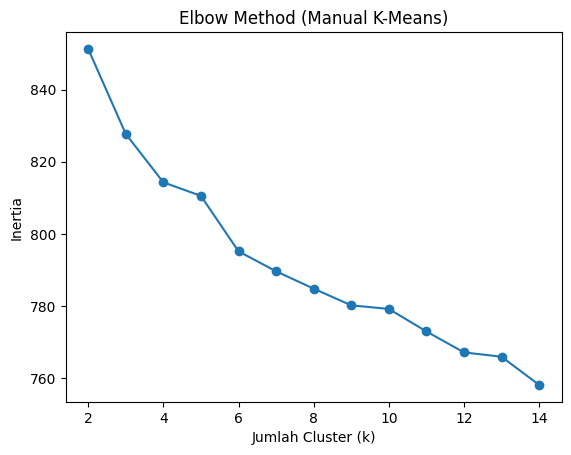

In [ ]:
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (Manual K-Means)')
plt.show()


In [ ]:
k = 8
labels, centroids = manual_kmeans(final_matrix, k)
data_filtered["Cluster"] = labels


In [ ]:
# ==========================================
# 1. FUNGSI JARAK EUCLIDEAN
# ==========================================
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


# ==========================================
# 2. K-MEANS MANUAL
# ==========================================
def manual_kmeans(X, k, max_iter=100, tol=1e-4):
    n_samples, n_features = X.shape

    # --------------------------------------
    # Langkah 1: Inisialisasi centroid (acak)
    # --------------------------------------
    np.random.seed(42)
    random_idx = np.random.choice(n_samples, k, replace=False)
    centroids = X[random_idx]

    for iteration in range(max_iter):
        # --------------------------------------
        # Langkah 2: Assign ke cluster terdekat
        # --------------------------------------
        clusters = [[] for _ in range(k)]
        labels = np.zeros(n_samples, dtype=int)

        for i, point in enumerate(X):
            distances = [euclidean(point, c) for c in centroids]
            cluster_id = np.argmin(distances)
            clusters[cluster_id].append(point)
            labels[i] = cluster_id

        # --------------------------------------
        # Langkah 3: Hitung centroid baru
        # --------------------------------------
        new_centroids = np.zeros((k, n_features))

        for idx, cluster in enumerate(clusters):
            if len(cluster) > 0:
                new_centroids[idx] = np.mean(cluster, axis=0)
            else:
                new_centroids[idx] = centroids[idx]   # jika cluster kosong

        # --------------------------------------
        # Langkah 4: Cek konvergensi
        # --------------------------------------
        shift = np.sqrt(np.sum((new_centroids - centroids) ** 2))

        if shift < tol:
            print(f"Konvergen pada iterasi ke-{iteration+1}")
            break

        centroids = new_centroids

    return labels, centroids


# ==========================================
# 3. MENJALANKAN KMEANS MANUAL
# ==========================================
k = 5  # nilai terbaik dari analisis elbow/silhouette
labels, centroids = manual_kmeans(final_matrix, k)

data_filtered['Cluster'] = labels

# ==========================================
# 4. CETAK HASIL CLUSTER
# ==========================================
for c in range(k):
    hotel_list = data_filtered[data_filtered['Cluster'] == c]['Hotel Name'].tolist()
    print(f"\nCluster {c+1} ({len(hotel_list)} hotel):")
    for h in hotel_list:
        print(" -", h)

Konvergen pada iterasi ke-15

Cluster 1 (174 hotel):
 - 18 suite villa loft
 - abi bali resort villas and spa
 - abia villa legian
 - adi assri beach resort & spa
 - adiwana dara ayu villas
 - agata villas
 - airis luxury villas & spa
 - alam candi dive resort
 - alam kulkul boutique resort
 - alam puisi villa
 - alam ubud culture, environment villas & residences
 - aleesha villas
 - alindra villa
 - amadea resort & villas seminyak bali
 - amala villas ubud
 - amatara arya ubud
 - anantara seminyak resort & spa
 - annora villas sanur
 - aq-va hotel & villas
 - aqua octaviana villa
 - argya santi resort
 - aria exclusive villa & spa
 - arkamara dijiwa ubud
 - askara villa
 - asri sari ubud resort & villa
 - astagina resort villa and spa
 - atta mesari ubud
 - avani seminyak bali resort
 - avisara villa and guesthouse
 - bagus agro pelaga
 - bali golden elephant
 - bali royal heritage villas
 - balitung villa seminyak
 - bayad ubud bali villa
 - beautiful bali villas
 - beraban beach hou

## Akurasi

In [ ]:
y_true = data_filtered['Rating'].values
y_pred = hybrid_scaled.mean(axis=1)

y_pred = ((y_pred - y_pred.min()) / (y_pred.max() - y_pred.min() + 1e-9)) * (y_true.max() - y_true.min()) + y_true.min()

mae = np.mean(np.abs(y_pred - y_true))
accuracy = 1 - (mae / (y_true.max() - y_true.min()))
print(f"=== Evaluasi Hybrid Recommendation System ===")
print(f"Akurasi Estimasi : {accuracy:.3f}")
print(f"MAE              : {mae:.3f}")


=== Evaluasi Hybrid Recommendation System ===
Akurasi Estimasi : 0.882
MAE              : 0.625


In [ ]:
y_true = data_filtered['Rating'].values
y_pred = hybrid_scaled.mean(axis=1)

y_pred = ((y_pred - y_pred.min()) / (y_pred.max() - y_pred.min() + 1e-9)) \
          * (y_true.max() - y_true.min()) + y_true.min()

mae = np.mean(np.abs(y_pred - y_true))
accuracy = 1 - (mae / (y_true.max() - y_true.min()))

threshold = 8.0
y_true_bin = (y_true >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)

tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
tn = np.sum((y_true_bin == 0) & (y_pred_bin == 0))

precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)
f1_score = 2 * (precision * recall) / (precision + recall + 1e-9)

print("=== Evaluasi Hybrid Recommendation System (Algoritma ICHM) ===")
print(f"Akurasi Estimasi : {accuracy:.3f}")
print(f"MAE              : {mae:.3f}")
print(f"Presisi          : {precision:.3f}")
print(f"Recall           : {recall:.3f}")
print(f"F1-Score         : {f1_score:.3f}")


=== Evaluasi Hybrid Recommendation System (Algoritma ICHM) ===
Akurasi Estimasi : 0.882
MAE              : 0.625
Presisi          : 0.907
Recall           : 0.790
F1-Score         : 0.845


## Ekspor Model

In [ ]:
import pickle
import os

os.makedirs("model", exist_ok=True)

with open("model/hybrid_model.pkl", "wb") as f:
    pickle.dump({
        "hybrid_sim": hybrid_sim,
        "content_sim": content_sim,
        "collab_sim": collab_sim,
        "data_filtered": data_filtered,
        "pivot_filtered": pivot_filtered
    }, f)

print("✅ Model hybrid (ICHM) berhasil disimpan ke folder /model/hybrid_model.pkl")


✅ Model hybrid (ICHM) berhasil disimpan ke folder /model/hybrid_model.pkl


In [ ]:
import json
import numpy as np

model_json = {
    # ================= MODEL =================
    "hybrid_sim": hybrid_sim.tolist(),
    "content_sim": content_sim.tolist(),
    "collab_sim": collab_sim.tolist(),

    # ================= DATA =================
    "data_filtered": data_filtered[[
        "Hotel Name",
        "location",
        "Facility",
        "Room Type",
        "Rating",
        "Price_raw"        # ⬅️ HARGA ASLI (RUPIAH)
    ]].to_dict(orient="records"),

    # ================= NORMALIZATION INFO =================
    "price_min": float(price_min),
    "price_max": float(price_max)
}

with open("model/hybrid_model.json", "w") as f:
    json.dump(model_json, f)

print("✅ Model berhasil disimpan dalam format JSON")


KeyError: "['Price_raw'] not in index"

In [ ]:
from google.colab import files
data_filtered.to_csv("hotel_cleaned.csv", index=False)
files.download("hotel_cleaned.csv")